# Предобработка данных TAIGA: gamma vs proton

Цель работы: подготовить данные Хилласа к обучению моделей классификации частиц: `gamma` или `proton`.

В этой части работы нужно:

1. Считать CSV-файлы с данными.
2. Проверить структуру и качество данных.
3. Построить распределения признаков для классов `gamma` и `proton`.
4. Исследовать связь признаков с целевым классом.
5. Сформировать итоговый набор признаков для последующего обучения моделей.

## Словарь признаков для текущих CSV

Ниже приведена рабочая расшифровка признаков, которые есть в текущих файлах `data/gamma.csv` и `data/proton.csv` и соотносятся с PDF `Parameters_Definitions_Report.pdf`.

Важное ограничение: PDF описывает более полные экспериментальные таблицы TAIGA-IACT02, а текущие CSV являются сокращёнными таблицами признаков для задачи `gamma` vs `proton`. Поэтому информация из PDF подходит к нашим данным только частично. Хорошо применимы разделы про Hillas-параметры, моменты формы изображения и параметры клининга. В текущих CSV нет многих полей наблюдений, времени, pointing-файлов, фона и темпа счёта: `por`, `time`, `unix_time_ns`, `delta_time`, `error_deg`, `tel_az`, `tel_el`, `source_az`, `source_el`, `CR400phe`, `CR_portion`, `median_background`, `MAD_background`, `tel_ra`, `tel_dec`, `source_ra`, `source_dec`, `tracking`, `good`, `star`, `weather_mark`, `alpha_c`. Поэтому в этой работе используйте только фактически присутствующие колонки.

| Колонка в текущих CSV | Описание |
|---|---|
| `event_number` | Номер события. В PDF: `event_numb`. |
| `numb_pix` | Число пикселей, прошедших клининг. |
| `num_islands` | Число островов в событии после клининга. |
| `size` | Суммарное число фотоэлектронов в событии. |
| `Xc[0]` | X-координата центра тяжести события. |
| `Yc[0]` | Y-координата центра тяжести события. |
| `con_selected_island` | Доля `size` в отобранном самом ярком острове. |
| `con2` | Доля `size` в двух самых ярких пикселях события. |
| `length[0]` | Момент второго порядка вдоль главной оси эллипса. |
| `width[0]` | Момент второго порядка вдоль малой оси эллипса. |
| `dist[0]` | Расстояние между центром тяжести эллипса и положением источника. В PDF: `dist1`. |
| `dist[1]` | Расстояние между центром тяжести эллипса и положением антиисточника. В PDF: `dist2`. |
| `a_axis[0]` | Коэффициент `a` уравнения `y = a*x + b`, характеризующий наклон эллипса относительно координатной сетки камеры. |
| `b_axis[0]` | Коэффициент `b` уравнения `y = a*x + b`. Этого поля нет в исходной таблице описаний, но оно согласуется с описанием `a_axis`. |
| `skewness_l` | Асимметрия события вдоль главной оси эллипса. |
| `skewness_w` | Асимметрия события вдоль малой оси эллипса. |
| `skewness` | Асимметрия события. При анализе нужно проверить, как этот вариант названия соотносится с моментами вдоль осей. |
| `kurtosis_l` | Эксцесс вдоль главной оси. |
| `kurtosis_w` | Эксцесс вдоль малой оси. |
| `kurtosis` | Эксцесс события. При анализе нужно проверить, как этот вариант названия соотносится с моментами вдоль осей. |
| `alpha[0]` | Угол между главной осью эллипса и направлением на источник. В PDF: `alpha1`. |
| `alpha[1]` | Угол между главной осью эллипса и направлением на антиисточник. В PDF: `alpha2`. |
| `source_x` | X-координата источника в камере в градусах. |
| `source_y` | Y-координата источника в камере в градусах. |
| `edge` | Индикатор наличия граничных пикселей камеры среди пикселей, прошедших клининг. |

Колонки без надежного описания из предоставленного словаря, но присутствующие в данных: `clean_number`, `axis_scatter`, `energy`, `azwidth[1]`, `miss[1]`, `x_max_coord`, `y_max_coord`, `x_ground`, `y_ground`, `tel_tet`, `tel_fi`, `source_tet`, `source_fi`, `Xmax`, `con1`, `con3`.

Для итогового выбора признаков важно не только название, но и проверка распределений, пропусков, корреляций и возможной утечки информации.

## Как выполнять работу

- Выполняйте задания строго по порядку.
- В кодовых ячейках даны только подсказки по нужным методам и направлению решения. Рабочий код нужно написать самостоятельно.
- После каждого задания заполните блок `Промежуточный вывод`.
- Не ограничивайтесь фразой "видно на графике". Пишите, какие именно признаки отличаются и почему это важно для будущей модели.
- В конце работы должен получиться список признаков `selected_features`, который можно использовать в следующем ноутбуке для обучения моделей.

## Подготовка окружения

Импортируйте библиотеки, которые понадобятся для анализа таблиц и визуализации.

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42

## Задание 1. Считать CSV-данные

В папке `data` лежат два подготовленных CSV-файла:

- `gamma.csv` - события класса gamma;
- `proton.csv` - события класса proton.

Считайте оба файла в pandas DataFrame и посмотрите первые строки.

In [111]:
# Подсказки:
# 1. Создайте переменные с путями к файлам: data/gamma.csv и data/proton.csv.
# 2. Считайте оба файла с помощью pandas: pd.read_csv(...).
# 3. Сохраните таблицы в переменные gamma и proton.
# 4. Выведите размер таблиц через .shape.
# 5. Посмотрите первые строки через .head() или display(...).

# Ваш код:
gammapath = 'data/gamma.csv'
protonpath = 'data/proton.csv'

gamma = pd.read_csv(gammapath)
proton = pd.read_csv(protonpath)

print('Размер таблицы gamma:', gamma.shape)
print('Размер таблицы proton:', proton.shape)

proton.head()

Размер таблицы gamma: (6218, 35)
Размер таблицы proton: (5218, 39)


,clean_number,event_number,axis_scatter,numb_pix,energy,size,Xc[0],Yc[0],con2,length[0],width[0],dist[0],dist[1],azwidth[1],miss[1],alpha[0],alpha[1],a_axis[0],b_axis[0],x_max_coord,y_max_coord,skewness_l,kurtosis_l,skewness_w,kurtosis_w,con1,con3,edge,source_x,source_y,x_ground,y_ground,tel_tet,tel_fi,source_tet,source_fi,Xmax,num_islands,con_selected_island
0,0,1,0,7,28.4757,169.972,-2.067280,1.696840,0.520998,0.374946,0.113381,2.674490,3.690510,0.223461,1.988420,20.59530,32.6014,-1.730280,-15.589900,-1.9899,1.566640,-0.251106,30.11550,-0.077952,0.719059,0.290089,0.691679,0,1.21,0,169.549,282.65400,0.651756,6.76840,0.603315,0.396753,248.061,1,1.0
1,1,1,2,7,28.4757,91.531,-0.384003,-0.310093,0.452721,0.297078,0.169732,0.493575,1.623880,0.188367,0.544063,8.33836,19.5748,0.591010,-0.689418,-0.1809,-0.313328,-0.012724,9.20917,-0.006222,0.996101,0.257487,0.593733,0,1.21,0,-322.057,164.01700,0.584419,6.72654,0.603315,0.396753,248.061,1,1.0
2,2,5,2,4,16.0010,80.916,-1.476070,0.112919,0.740002,0.178342,0.129863,1.480390,2.688450,0.152468,1.757060,42.77790,40.8105,0.792684,10.638300,-1.4472,0.000000,-0.169553,1.64637,0.851977,0.381498,0.524408,0.884794,1,1.21,0,-386.391,-127.19000,0.639566,7.09372,0.668052,0.739303,385.763,1,1.0
3,3,16,1,13,34.9258,268.940,1.289450,0.951275,0.320183,0.523219,0.195980,1.602370,0.954587,0.237271,0.263181,32.80450,16.0038,2.635580,-20.291600,1.0854,0.626656,0.051572,80.14620,-0.521689,2.260630,0.173555,0.421949,0,1.21,0,-403.429,125.84600,0.590211,6.20354,0.611111,-0.060677,406.682,1,1.0
4,4,16,5,13,34.9258,401.381,2.971370,0.386676,0.338048,0.456254,0.172919,2.996430,1.803320,0.456225,1.803180,85.72990,89.3027,-4.835400,122.342000,3.0753,0.313328,-0.336844,55.13750,-0.063575,1.723790,0.174047,0.470954,0,1.21,0,-328.579,-4.94562,0.584870,6.12496,0.611111,-0.060677,406.682,1,1.0


### Промежуточный вывод 1

Заполните после выполнения кода:

- Сколько строк и колонок в каждом файле?
- Какие первые признаки вы видите в таблицах?
- Есть ли признаки, которые уже по названию выглядят как служебные или идентификаторы событий?

**Ваш вывод:**

> 1. В таблице гамма 6218 строк и 35 колонок, в таблице протон 5218 строк и 39 колонок
> 2. Energy, size, length, width, alpha
> 3. Все что перечислил но кроме энергии, она вроде как ничего не дает. Основные - size length width

<span style="background-color: #d9ead3; color: #274e13; padding: 2px 6px; border-radius: 4px;"><b>Проверка:</b> CSV-файлы считаны корректно.</span> Размеры таблиц указаны правильно: `gamma` содержит `6218` строк и `35` колонок, `proton` содержит `5218` строк и `39` колонок. Код использует `pd.read_csv(...)`, сохраняет таблицы в отдельные переменные и выводит размеры через `.shape`.

<span style="background-color: #fff2cc; color: #7f6000; padding: 2px 6px; border-radius: 4px;"><b>Совет:</b> стоит вывести первые строки обеих таблиц, а не только `proton.head()`.</span> По заданию нужно посмотреть первые строки и `gamma`, и `proton`, чтобы сразу увидеть, совпадает ли структура файлов и какие признаки есть в каждом классе.

<span style="background-color: #f4cccc; color: #990000; padding: 2px 6px; border-radius: 4px;"><b>Ошибка:</b> в выводе неверно отвечен вопрос про служебные признаки.</span> Служебные признаки - это колонки, которые помогают хранить, нумеровать, связывать или технически описывать строки данных, но сами по себе не описывают физические свойства события и обычно не должны использоваться как признаки модели. Например, `event_number` похож на идентификатор события, а `clean_number` - на номер/метку этапа обработки. А вот `energy`, `size`, `length[0]`, `width[0]`, `alpha[0]` выглядят как физические признаки, поэтому называть их служебными нельзя без дополнительного обоснования. Нужно еще раз посмотреть на названия колонок и отдельно выписать, какие признаки ты считаешь служебными и почему.

## Задание 2. Объединить данные и добавить метку класса

Объедините данные `gamma` и `proton` в одну таблицу. Перед объединением добавьте информацию о классе события:

- `target = 0` для `gamma`;
- `target = 1` для `proton`.

После объединения сохраните результат в переменную `df`.

In [31]:
# Подсказки:
# 1. Сделайте копии таблиц gamma и proton через .copy().
# 2. Добавьте в каждую копию числовую колонку target.
# 3. Объедините таблицы через pd.concat(..., ignore_index=True).
# 4. Проверьте размер df и посмотрите несколько строк.

# Ваш код:
gammacopy = gamma.copy()
protoncopy = proton.copy()

gammacopy['target'] = 0
protoncopy['target'] = 1

df = pd.concat([gammacopy, protoncopy], ignore_index=True)
print(df.shape)
df.head(15)

(11436, 42)


,clean_number,event_number,axis_scatter,numb_pix,energy,size,Xc[0],Yc[0],con2,length[0],width[0],dist[0],dist[1],azwidth[1],miss[1],alpha[0],alpha[1],a_axis[0],b_axis[0],x_max_coord,y_max_coord,skewness,kurtosis,edge,source_x,source_y,x_ground,y_ground,tel_tet,tel_fi,source_tet,source_fi,Xmax,num_islands,con_selected_island,target,skewness_l,kurtosis_l,skewness_w,kurtosis_w,con1,con3
0,0,1,1,21,192.9010,903.418,1.369730,-2.416260,0.343822,0.706498,0.122870,2.77750,2.77758,0.123940,0.064859,1.334930,1.338030,-1.863970,1.134940,1.2663,-2.193290,0.412741,354.0430,1,-0.000172,-3.103450e-10,485.3260,171.9310,0.695834,6.21157,0.695834,-0.071617,409.105,1,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,4,24,192.9010,1388.880,-2.460750,0.711740,0.354539,0.698548,0.166367,2.56161,2.56145,0.166931,0.051739,1.158470,1.157400,-0.311280,-0.449759,-2.1708,0.626656,0.509002,345.2810,1,-0.000172,-3.103450e-10,-159.7340,-333.3390,0.695834,6.21157,0.695834,-0.071617,409.105,1,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1,7,13,192.9010,369.733,-0.612322,-3.264150,0.340513,0.551291,0.143484,3.32109,3.32105,0.146999,0.199367,3.438680,3.441600,3.991980,-6.797440,-0.5427,-2.819950,-0.226941,112.9880,0,-0.000172,-3.103450e-10,726.0700,-160.2360,0.695834,6.21157,0.695834,-0.071617,409.105,1,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1,9,13,192.9010,455.150,0.261173,3.177410,0.388384,0.542986,0.139691,3.18813,3.18814,0.139691,0.002199,0.036433,0.039520,12.261400,-0.206795,0.1809,2.819950,0.040126,107.7320,0,-0.000172,-3.103450e-10,-680.5040,90.0432,0.695834,6.21157,0.695834,-0.071617,409.105,1,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,4,2,1,5,30.2981,119.634,-2.490450,-0.030344,0.566160,0.381089,0.090839,2.49064,2.49049,0.091882,0.092892,2.137600,2.137560,0.049532,0.771256,-2.8944,0.000000,-0.557556,24.1858,0,-0.000145,-2.866540e-10,276.5590,-273.8100,0.570295,7.05519,0.570295,0.772003,380.335,1,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN
5,5,2,7,14,30.2981,466.107,-1.605750,-0.793270,0.416544,0.523761,0.161558,1.79101,1.79088,0.163037,0.078781,2.523320,2.521270,0.550062,0.746209,-1.0854,-0.626656,0.552572,111.1520,1,-0.000145,-2.866540e-10,248.1360,-67.7066,0.570295,7.05519,0.570295,0.772003,380.335,1,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN
6,6,3,1,19,125.4810,705.492,2.401260,1.527320,0.264095,0.726237,0.157264,2.84583,2.84569,0.157284,0.010111,0.205357,0.203576,0.641095,-0.100464,1.8090,1.253310,0.072134,301.7860,0,0.000165,-3.674600e-10,-328.1900,221.4750,0.572811,6.61030,0.572811,0.327123,411.241,1,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN
7,7,3,3,26,125.4810,2437.510,-1.856170,0.418271,0.456062,0.709922,0.145413,1.90272,1.90288,0.145526,0.015679,0.471011,0.472101,-0.233995,-0.133200,-1.2663,0.313328,1.088530,532.7280,1,0.000165,-3.674600e-10,14.4279,-233.4710,0.572811,6.61030,0.572811,0.327123,411.241,1,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN
8,8,3,7,5,125.4810,151.253,-1.643140,2.812910,0.705123,0.321049,0.069422,3.25766,3.25775,0.070326,0.116805,2.052240,2.054750,-1.861960,-2.044440,-1.6281,2.819950,-0.531553,15.1958,0,0.000165,-3.674600e-10,-421.6090,-424.4730,0.572811,6.61030,0.572811,0.327123,411.241,1,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN
9,9,4,3,14,65.4540,613.704,0.874302,-2.452030,0.304156,0.616351,0.133390,2.60324,2.60318,0.133392,0.003627,0.076637,0.079830,-2.792740,-0.085647,0.7236,-1.879970,0.057651,174.0740,0,0.000154,-3.523360e-10,226.9060,219.5620,0.531141,6.74963,0.531141,0.466453,552.444,1,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN


### Промежуточный вывод 2

Ответьте:

- Сколько строк получилось после объединения?
- Что означает значение `target = 0` и `target = 1`?
- Что вы заметили при первом просмотре объединённой таблицы?

**Ваш вывод:**

> Получилось 11436 строк
> как я понял, таргет - значение для отличия гаммы и протона т.е классификация
> добавился признак таргет и также из-за того что мы использовали ignore_index=True наши данные объединились без проблем и порядок правильный

<span style="background-color: #d9ead3; color: #274e13; padding: 2px 6px; border-radius: 4px;"><b>Проверка:</b> объединение выполнено корректно.</span> Таблицы скопированы через `.copy()`, метка класса добавлена правильно: `target = 0` для `gamma` и `target = 1` для `proton`. Затем данные объединены через `pd.concat(..., ignore_index=True)`, итоговое число строк `11436` указано верно.

<span style="background-color: #f4cccc; color: #990000; padding: 2px 6px; border-radius: 4px;"><b>Ошибка:</b> вопрос о том, что было замечено при первом просмотре объединенной таблицы, фактически остался без ответа.</span> Важно не просто написать, что данные объединились без проблем, а проверить структуру после объединения: какие колонки есть в обеих таблицах, какие есть только в `gamma`, какие есть только в `proton`. Так как у `gamma` `35` колонок, а у `proton` `39`, после `pd.concat` часть колонок будет уникальной для одного класса и даст пропуски (`NaN`) для другого. Нужно явно вывести различия, например через `set(gamma.columns) - set(proton.columns)` и `set(proton.columns) - set(gamma.columns)`, и описать это в выводе.

## Задание 3. Осмотреть структуру объединённой таблицы

Изучите структуру `df`: размеры, названия колонок, типы данных и несколько случайных строк. На этом этапе не исправляйте данные, а только зафиксируйте наблюдения.

In [69]:
# Подсказки:
# 1. Используйте .shape, .columns, .dtypes или .info().
# 2. Посмотрите первые, последние и случайные строки через .head(), .tail(), .sample().
# 3. Выпишите наблюдения, которые могут быть важны для дальнейшей предобработки.

# Ваш код:
df.shape
df.columns
df.dtypes
df.info()

print('Первые 5 cтрок')
df.head(5)

print('Последние 5 строк')
df.tail(5)

print('Случайные 10строк')
df.sample(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11436 entries, 0 to 11435
Data columns (total 42 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   clean_number         11436 non-null  int64  
 1   event_number         11436 non-null  int64  
 2   axis_scatter         11436 non-null  int64  
 3   numb_pix             11436 non-null  int64  
 4   energy               11436 non-null  float64
 5   size                 11436 non-null  float64
 6   Xc[0]                11436 non-null  float64
 7   Yc[0]                11436 non-null  float64
 8   con2                 11436 non-null  float64
 9   length[0]            11433 non-null  float64
 10  width[0]             11433 non-null  float64
 11  dist[0]              11436 non-null  float64
 12  dist[1]              11436 non-null  float64
 13  azwidth[1]           11436 non-null  float64
 14  miss[1]              11436 non-null  float64
 15  alpha[0]             11436 non-null 

,clean_number,event_number,axis_scatter,numb_pix,energy,size,Xc[0],Yc[0],con2,length[0],width[0],dist[0],dist[1],azwidth[1],miss[1],alpha[0],alpha[1],a_axis[0],b_axis[0],x_max_coord,y_max_coord,skewness,kurtosis,edge,source_x,source_y,x_ground,y_ground,tel_tet,tel_fi,source_tet,source_fi,Xmax,num_islands,con_selected_island,target,skewness_l,kurtosis_l,skewness_w,kurtosis_w,con1,con3
4337,4337,1743,2,9,70.84190,134.160,-0.061342,3.161790,0.328548,0.576284,0.154067,3.162390,3.162390,0.155818,0.132636,2.40082,2.40379,-16.292500,17.93010,-0.1809,4.073270,0.170758,129.1510,1,-0.000163,-3.045000e-10,-690.6600,-67.6978,0.653622,6.35072,0.653622,0.067533,384.958,1,1.000000,0,NaN,NaN,NaN,NaN,NaN,NaN
7467,184,731,9,10,28.78610,281.089,-2.626610,-2.571330,0.344393,0.388200,0.170168,3.675700,4.618580,0.324242,3.653400,62.84150,52.28120,-0.333642,-28.58770,-2.5326,-2.506620,NaN,NaN,1,1.210000,0.000000e+00,158.6040,-231.9780,0.579402,7.25106,0.630895,0.932913,304.595,1,1.000000,1,-0.008655,25.51530,-0.098789,1.071570,0.183593,0.481371
549,549,220,3,5,31.12110,86.115,-2.414250,-0.657943,0.567253,0.355684,0.089886,2.502300,2.502480,0.110263,0.464392,10.69560,10.69450,0.079557,-3.86297,-2.5326,-0.626656,-0.405524,18.7244,0,0.000185,-3.896270e-10,36.0056,-442.9940,0.654483,6.05644,0.654483,-0.226737,381.909,2,0.675279,0,NaN,NaN,NaN,NaN,NaN,NaN
4131,4131,1657,9,13,194.41800,636.308,-2.586690,-1.345680,0.381210,0.482556,0.153864,2.915790,2.915940,0.154747,0.105223,2.06646,2.06800,0.566959,1.00217,-2.5326,-1.253310,-0.219061,72.5204,1,0.000170,-3.736770e-10,129.4090,-424.0520,0.592337,6.03149,0.592337,-0.251687,463.401,1,1.000000,0,NaN,NaN,NaN,NaN,NaN,NaN
2061,2061,840,9,19,199.69200,664.878,1.656720,2.923250,0.257449,0.663358,0.180863,3.360070,3.359990,0.182053,0.109396,1.86829,1.86579,1.906850,-1.95578,1.8090,3.133280,-0.191960,244.7980,1,0.000168,-3.718860e-10,-102.1180,530.2270,0.586533,5.33672,0.586533,-0.946457,440.318,1,1.000000,0,NaN,NaN,NaN,NaN,NaN,NaN
8312,1029,3985,5,6,12.01330,217.685,1.093290,3.359750,0.605329,0.243523,0.147199,3.533160,3.361770,0.170705,1.497950,6.44591,26.46070,2.197220,7.93984,1.2663,3.446600,NaN,NaN,1,1.210000,0.000000e+00,128.0770,-176.8440,0.705865,5.65758,0.634285,-0.584527,263.626,1,1.000000,1,0.585173,5.36640,0.661569,0.412029,0.388465,0.767003
10327,973,3719,3,21,30.13220,1189.020,0.419943,3.677500,0.384894,0.368580,0.258750,3.701400,3.761410,0.355216,3.487380,86.63390,67.99450,-0.174180,31.09990,0.7236,3.759930,NaN,NaN,1,1.210000,0.000000e+00,-74.0114,-81.3472,0.585598,5.83896,0.527124,-0.397667,418.563,1,1.000000,1,0.444638,26.33440,-0.521839,9.616190,0.196771,0.505266
6030,6030,2390,2,8,92.55090,205.437,2.482270,-2.163170,0.377727,0.470434,0.114883,3.292560,3.292680,0.124177,0.340223,5.92901,5.93080,-1.072350,4.13508,2.3517,-2.193290,0.052164,64.7567,1,-0.000156,-2.984360e-10,245.3910,489.1500,0.620707,6.63303,0.620707,0.349843,441.027,1,1.000000,0,NaN,NaN,NaN,NaN,NaN,NaN
10739,343,1329,9,11,22.56350,226.342,0.844661,-0.501856,0.411620,0.420820,0.204951,0.982502,0.620751,0.230771,0.179142,78.56350,16.77350,2.858710,-24.18320,0.7236,-0.626656,NaN,NaN,0,1.210000,0.000000e+00,-301.5670,168.5500,0.631242,6.02143,0.667720,-0.253727,364.573,1,1.000000,1,-0.623608,44.68720,-1.132360,4.241190,0.209289,0.593027
8963,641,2530,4,5,9.47489,83.709,-0.455341,1.771160,0.588013,0.213289,0.155185,1.828750,2.431120,0.159428,0.607078,14.35810,14.46040,-1.820810,7.81151,-0.3618,1.879970,NaN,NaN,0,1.210000,0.000000e+00,236.6470,67.3808,0.694834,6.03246,0.649976,-0.281057,320.380,1,1.000000,1,0.273987,2.68844,-0.272670,0.356384,0.311185,0.751556


### Промежуточный вывод 3

Ответьте:

- Какие типы данных есть в таблице?
- Какие колонки выглядят физическими признаками, а какие служебными?
- Какие особенности структуры таблицы нужно учесть перед выбором признаков?

**Ваш вывод:**

> В таблице есть float64 - дробные числа для таких параметров как energy, size, length, width.., также int64 - целые числа для target, clean number, event number
> физические это все что связано с размером, энергия, Xc[0], Yc[0], служебные - target, event number, clean number, num_islands
> думаю нам нужно не учитывать такие признаки как event number, clean number так как они не дают важной информации и также нужно учесть что в некоторых колоннах много пропусков (NaN)

<span style="background-color: #d9ead3; color: #274e13; padding: 2px 6px; border-radius: 4px;"><b>Проверка:</b> структура объединенной таблицы в целом осмотрена.</span> В коде вызван `df.info()`, поэтому видны размер таблицы, названия колонок, типы данных и количество непустых значений. Также выведены случайные строки через `df.sample(10)`, что соответствует заданию посмотреть несколько случайных наблюдений.

<span style="background-color: #fff2cc; color: #7f6000; padding: 2px 6px; border-radius: 4px;"><b>Совет:</b> часть команд в ячейке фактически не отображается как отдельный результат.</span> В коде есть строки `df.shape`, `df.columns`, `df.dtypes`, `df.head(5)`, `df.tail(5)`, но в одной ячейке Jupyter автоматически показывает только последний неявный вывод. Лучше использовать `print(...)` или `display(...)`, например `display(df.head())`, `display(df.tail())`, `display(df.dtypes)`, чтобы проверка структуры была явно видна в ноутбуке.

<span style="background-color: #f4cccc; color: #990000; padding: 2px 6px; border-radius: 4px;"><b>Ошибка:</b> вывод про служебные и физические признаки нужно уточнить.</span> `target`, `event_number`, `clean_number` действительно выглядят служебными или техническими колонками, но `num_islands` не стоит автоматически относить к служебным: это число островов после клининга, то есть характеристика структуры события, и ее смысл нужно анализировать отдельно. Служебные признаки - это идентификаторы, метки классов или технические поля, которые не описывают физику события напрямую. Нужно пересмотреть список колонок и аккуратно разделить: физические признаки, целевая переменная, идентификаторы и спорные технические/служебные поля.

## Задание 4. Проверить качество таблицы

Проверьте:

- баланс классов;
- типы данных;
- пропуски;
- полные дубликаты строк.

Эти проверки нужны до построения распределений и выбора признаков.

In [77]:
# Подсказки:
# 1. Посчитайте число объектов каждого класса через value_counts().
# 2. Посчитайте доли классов через value_counts(normalize=True).
# 3. Проверьте типы данных через .dtypes.
# 4. Найдите долю пропусков по колонкам через .isna().mean().
# 5. Проверьте полные дубликаты через .duplicated().sum().

# Ваш код:
print('Число объектов каждого класса')
print(df['target'].value_counts())

print('Доли классов')
print(df['target'].value_counts(normalize=True))

print('Типы данных')
print(df.dtypes)

print('Доля пропусков по колонкам')
missingshares = df.isna().mean()
print(missingshares[missingshares > 0].sort_values(ascending=False).head(10))

print('Полные дубликаты')
print(df.duplicated().sum())

Число объектов каждого класса
target
0    6218
1    5218
Name: count, dtype: int64
Доли классов
target
0    0.543722
1    0.456278
Name: proportion, dtype: float64
Типы данных
clean_number             int64
event_number             int64
axis_scatter             int64
numb_pix                 int64
energy                 float64
size                   float64
Xc[0]                  float64
Yc[0]                  float64
con2                   float64
length[0]              float64
width[0]               float64
dist[0]                float64
dist[1]                float64
azwidth[1]             float64
miss[1]                float64
alpha[0]               float64
alpha[1]               float64
a_axis[0]              float64
b_axis[0]              float64
x_max_coord            float64
y_max_coord            float64
skewness               float64
kurtosis               float64
edge                     int64
source_x               float64
source_y               float64
x_ground          

### Промежуточный вывод 4

Ответьте:

- Сильно ли отличаются размеры классов?
- Есть ли пропуски? Если есть, в каких колонках?
- Есть ли проблема с типами данных?
- Нужно ли сейчас удалять дубликаты или достаточно зафиксировать их наличие?

**Ваш вывод:**

> 1. Размеры классов отличаются не сильно
> 2. еcть пропуски в колонках skewness, kurtosis по 45%, con1 и con3 по 54%, skewness_l/w, kurtosis_l/w также по 54%
> 3. с типами данных нет проблем, все 42 колонки распознаны как int64 или float64
> 4. на данном этапе мы не удаляем дубликаты а просто смотрим их наличие т.к мы проверяем качество таблицы

<span style="background-color: #d9ead3; color: #274e13; padding: 2px 6px; border-radius: 4px;"><b>Проверка:</b> основные проверки качества таблицы выполнены.</span> Ты посчитал баланс классов через `value_counts()`, доли классов через `value_counts(normalize=True)`, проверил типы данных, долю пропусков и полные дубликаты. Вывод про баланс классов корректный: классы отличаются не критично, примерно `54.4%` gamma и `45.6%` proton. Типы данных тоже в порядке: все колонки числовые, `float64` или `int64`. Полных дубликатов нет.

<span style="background-color: #f4cccc; color: #990000; padding: 2px 6px; border-radius: 4px;"><b>Ошибка:</b> вывод по пропускам неполный.</span> Ты правильно заметил крупные группы пропусков: `skewness`, `kurtosis`, `con1`, `con3`, `skewness_l`, `skewness_w`, `kurtosis_l`, `kurtosis_w`. Но в таблице есть и небольшие пропуски в важных физических признаках: `a_axis[0]`, `b_axis[0]`, `length[0]`, `width[0]`. Их нельзя игнорировать только потому, что доля маленькая: `length[0]` и `width[0]` дальше рассматриваются как кандидаты для модели, поэтому пропуски в них нужно явно зафиксировать.

## Задание 5. Выбрать числовые признаки для первичного анализа

Не все числовые колонки должны становиться признаками модели. Например, `target` - это целевая переменная, а `event_number` и `clean_number` похожи на идентификаторы.

На этом шаге сформируйте список числовых колонок, которые можно анализировать как потенциальные признаки.

In [93]:
# Подсказки:
# 1. Составьте список технических колонок, которые не должны быть признаками модели.
#    Например: target, event_number, clean_number.
# 2. Получите числовые колонки через select_dtypes(include="number").
# 3. Исключите технические колонки из списка числовых.
# 4. Сохраните результат в переменную numeric_columns.
# 5. Изучите описательные статистики через describe().

# Ваш код:
techcolumns = ['target', 'event_number', 'clean_number', 'edge']

allnumerical = df.select_dtypes(include="number")

numeric_columns = [col for col in allnumerical if col not in techcolumns]

df[numeric_columns].describe()

,axis_scatter,numb_pix,energy,size,Xc[0],Yc[0],con2,length[0],width[0],dist[0],dist[1],azwidth[1],miss[1],alpha[0],alpha[1],a_axis[0],b_axis[0],x_max_coord,y_max_coord,skewness,kurtosis,source_x,source_y,x_ground,y_ground,tel_tet,tel_fi,source_tet,source_fi,Xmax,num_islands,con_selected_island,skewness_l,kurtosis_l,skewness_w,kurtosis_w,con1,con3
count,11436.000000,11436.000000,11436.000000,11436.000000,11436.000000,11436.000000,11436.000000,11433.000000,11433.000000,11436.000000,11436.000000,11436.000000,11436.000000,11436.000000,11436.000000,11418.000000,11418.000000,11436.000000,11436.000000,6203.000000,6203.000000,11436.000000,1.143600e+04,11436.000000,11436.000000,11436.000000,11436.000000,11436.000000,11436.000000,11436.000000,11436.000000,11436.000000,5215.000000,5215.000000,5.215000e+03,5215.000000,5218.000000,5218.000000
mean,4.543022,13.020811,59.409359,778.508505,0.032525,0.038650,0.450421,0.462816,0.149778,2.414985,2.498892,0.208412,0.833272,22.137386,21.919475,1.096209,3.783687,0.031811,0.035645,0.377789,161.759255,0.552099,-1.825393e-10,2.813664,1.513150,0.614224,6.251777,0.613654,-0.031117,389.402757,1.034453,0.996096,-0.020728,62.844856,5.308322e+07,2.577248,0.283513,0.622443
std,2.888722,7.950333,51.850892,1381.403504,1.786147,1.823893,0.123394,0.147151,0.040695,0.828731,0.947788,0.113656,1.111658,27.862429,27.648586,116.626209,709.888659,1.739832,1.770503,0.536170,149.039289,0.602707,1.702263e-10,265.726970,241.972091,0.055483,0.608765,0.049828,0.607476,71.619773,0.194463,0.029870,0.524891,134.202041,3.833403e+09,8.423034,0.088436,0.136114
min,0.000000,4.000000,1.432260,42.972000,-4.104700,-3.970900,0.139075,0.112614,0.000000,0.020805,0.024277,0.000000,0.000000,0.000000,0.000000,-2664.050000,-26658.800000,-4.341600,-4.073270,-1.646010,1.621960,-0.000173,-3.972430e-10,-833.938000,-714.717000,0.448590,5.123780,0.523643,-1.046740,164.219000,1.000000,0.404299,-1.937150,0.436763,-4.611340e+00,-0.000006,0.069893,0.206648
25%,2.000000,8.000000,21.741700,176.051500,-1.417403,-1.453955,0.354226,0.347191,0.127230,1.841697,1.837923,0.136916,0.050001,1.335095,1.345722,-1.070800,-3.180260,-1.266300,-1.253310,-0.005998,51.784100,-0.000140,-3.534890e-10,-182.353250,-166.271500,0.570454,5.727862,0.571629,-0.555157,344.572500,1.000000,1.000000,-0.383163,10.150600,-3.289490e-01,0.417497,0.218088,0.526257
50%,5.000000,11.000000,35.897900,330.722500,0.038649,0.020694,0.432309,0.451826,0.146419,2.530485,2.555830,0.163069,0.186681,4.667595,4.734050,-0.002742,0.016592,0.000000,0.000000,0.266033,115.051000,0.000190,-2.829285e-10,3.096225,1.003858,0.615563,6.233390,0.614041,-0.047597,385.108000,1.000000,1.000000,-0.014628,25.420300,-8.522210e-03,1.063590,0.272363,0.613052
75%,7.000000,16.000000,89.899800,747.003250,1.494722,1.539242,0.532190,0.572501,0.166896,3.069758,3.131992,0.249218,1.413947,42.103750,41.706950,1.043928,3.667747,1.447200,1.566640,0.682511,228.842500,1.210000,0.000000e+00,185.073250,170.097000,0.658352,6.766280,0.656413,0.487913,426.378000,1.000000,1.000000,0.354123,62.078200,3.204585e-01,2.157815,0.336160,0.715511
max,9.000000,125.000000,199.824000,22332.900000,3.802900,4.346570,0.902065,1.137210,0.619735,4.525390,5.501260,1.136490,5.138470,89.997000,89.994400,9605.710000,59328.200000,3.979800,4.699910,2.583750,1856.010000,1.210000,0.000000e+00,845.710000,815.260000,0.780077,7.446400,0.698118,1.047060,940.963000,5.000000,1.000000,1.794480,3573.890000,2.768290e+11,273.734000,0.823910,0.976166


### Промежуточный вывод 5

Ответьте:

- Какие колонки вы исключили как технические?
- Все ли оставшиеся числовые колонки физически осмысленны как признаки?
- Есть ли признаки с очень разными масштабами значений?

**Ваш вывод:**

> 1. Я исключил target, event_number, clean_number, edge.
> 2. Осмыслены все кроме тех на которых нет надежного описания - axis_scatter, energy, azwidth[1], miss[1], x_max_coord, y_max_coord, x_ground, y_ground, tel_tet, tel_fi, source_tet, source_fi, Xmax, con1, con3
> 3. Есть признак skewness_w где max - 2.76.....e+11, но 75% это 3.204585e-01, довольно разные значения
> также у skewness_l, kurtosis_l, skewness_w, kurtosis_w, con1, con3 есть много пропусков так как count составляет 5215 или 5218 из 11436 строк

<span style="background-color: #d9ead3; color: #274e13; padding: 2px 6px; border-radius: 4px;"><b>Проверка:</b> базовая логика отбора числовых колонок выполнена правильно.</span> Ты получил числовые колонки через `select_dtypes(include="number")`, исключил явные технические поля `target`, `event_number`, `clean_number`, `edge` и сохранил результат в `numeric_columns`. Также правильно посмотрел `describe()`: по нему видно, что у признаков разные масштабы и что у части колонок есть большие пропуски.

<span style="background-color: #f4cccc; color: #990000; padding: 2px 6px; border-radius: 4px;"><b>Ошибка:</b> список `numeric_columns` пока нельзя считать готовым списком потенциальных признаков для анализа.</span> После исключения только `target`, `event_number`, `clean_number`, `edge` в списке остаются колонки, которые есть только у одного класса: `skewness`, `kurtosis` есть только у `gamma`, а `skewness_l`, `kurtosis_l`, `skewness_w`, `kurtosis_w`, `con1`, `con3` есть только у `proton`. Такие признаки опасны: модель может выучить не физику события, а сам факт наличия/отсутствия значения, то есть получить утечку информации о классе. Нужно явно сравнить наборы колонок `gamma` и `proton`, отметить признаки, которые есть только в одном файле, и не смешивать их с обычными кандидатами без отдельного решения.

<span style="background-color: #f4cccc; color: #990000; padding: 2px 6px; border-radius: 4px;"><b>Ошибка:</b> вывод про физическую осмысленность признаков слишком общий.</span> Ты перечислил колонки "без надежного описания", но не разделил их на разные типы: физические признаки события, координаты/положение источника, параметры телескопа/наблюдения, признаки с риском утечки и признаки с большим количеством пропусков. Например, `source_x`, `source_y`, `tel_tet`, `tel_fi`, `source_tet`, `source_fi`, `x_ground`, `y_ground` нельзя просто оставить в общем списке числовых признаков без объяснения, что они означают и почему их можно использовать в модели. Нужно сделать более аккуратную классификацию колонок перед дальнейшим анализом.

## Задание 6. Построить распределения признаков

Постройте распределения признаков отдельно для классов `gamma` и `proton`.

Начните с нескольких признаков, которые встречались в исследовательском ноутбуке: `width[0]`, `length[0]`, `alpha[0]`, `miss[1]`, `azwidth[1]`, `dist[1]`, `Xc[0]`, `Yc[0]`, `numb_pix`.

Затем добавьте 2-3 признака по своему выбору.

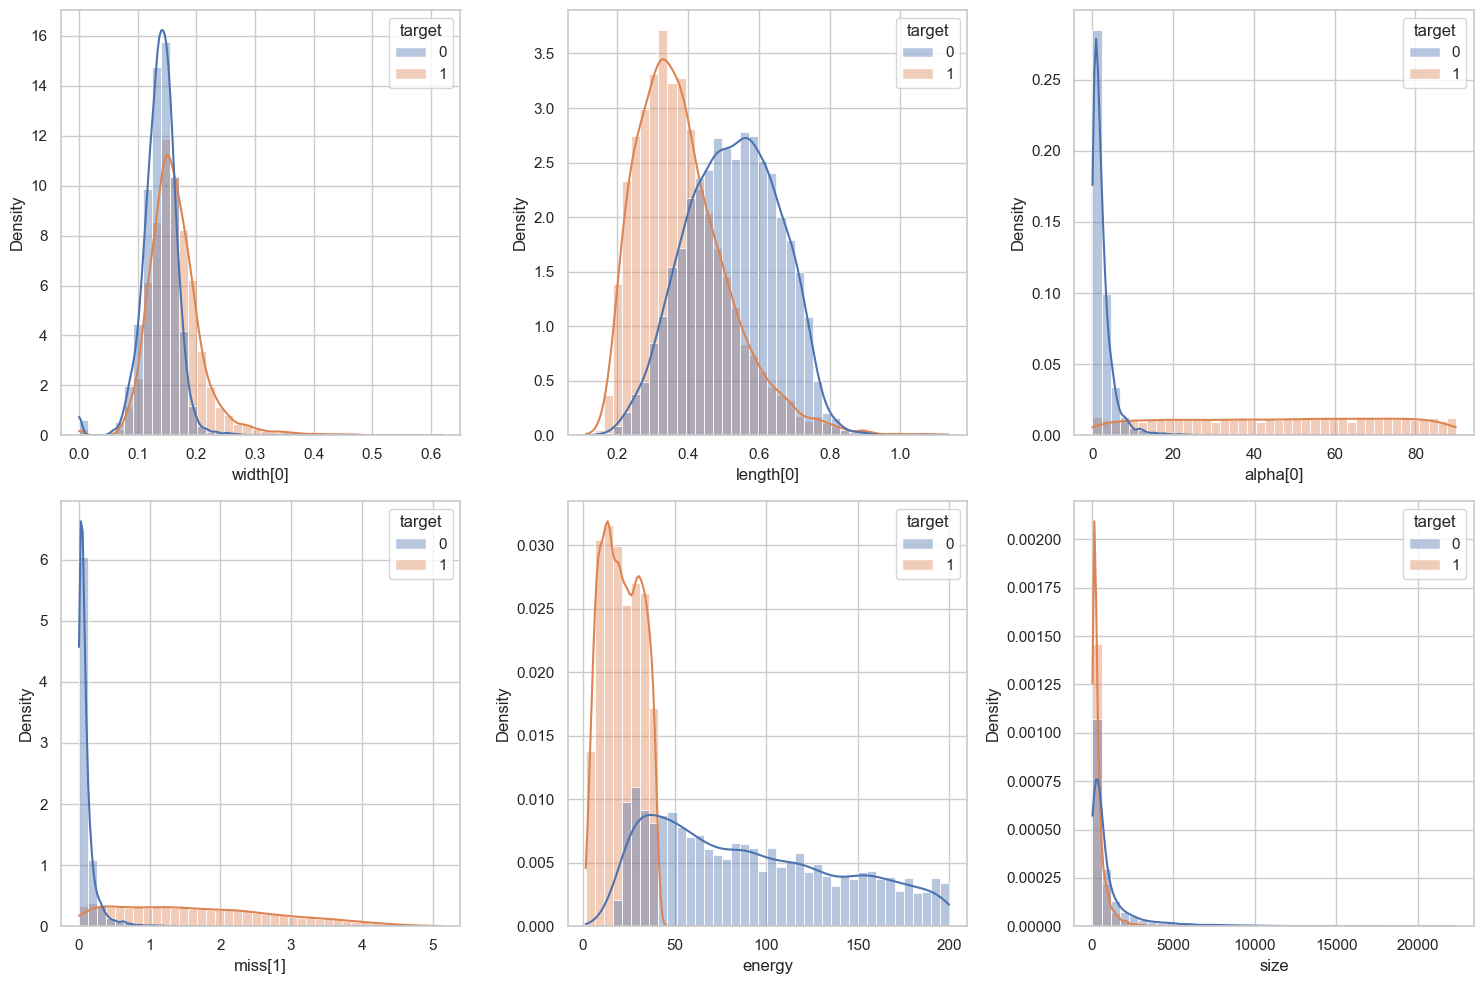

In [101]:
# Подсказки:
# 1. Создайте список features_to_plot с несколькими признаками для анализа.
#    Можно начать с width[0], length[0], alpha[0], miss[1], azwidth[1], dist[1], Xc[0], Yc[0], numb_pix.
# 2. Для каждого признака постройте распределение отдельно для gamma и proton.
# 3. Удобные функции: sns.histplot(..., hue="target") или sns.kdeplot(..., hue="target").
# 4. Настройте bins, alpha, stat="density" и common_norm=False, если используете histplot.
# 5. Подпишите графики и сравните формы распределений.

# Ваш код:
features_to_plot = ['width[0]', 'length[0]', 'alpha[0]', 'miss[1]', 'azwidth[1]', 'dist[1]', 'Xc[0]', 'Yc[0]', 'numb_pix']
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))

sns.histplot(data=df, x='width[0]', hue='target', stat='density', common_norm=False, kde=True, alpha=0.4, bins=40, ax=axes[0, 0])
sns.histplot(data=df, x='length[0]', hue='target', stat='density', common_norm=False, kde=True, alpha=0.4, bins=40, ax=axes[0, 1])
sns.histplot(data=df, x='alpha[0]', hue='target', stat='density', common_norm=False, kde=True, alpha=0.4, bins=40, ax=axes[0, 2])
sns.histplot(data=df, x='miss[1]', hue='target', stat='density', common_norm=False, kde=True, alpha=0.4, bins=40, ax=axes[1, 0])
sns.histplot(data=df, x='energy', hue='target', stat='density', common_norm=False, kde=True, alpha=0.4, bins=40, ax=axes[1, 1])
sns.histplot(data=df, x='size', hue='target', stat='density', common_norm=False, kde=True, alpha=0.4, bins=40, ax=axes[1, 2])
plt.tight_layout()
plt.show()

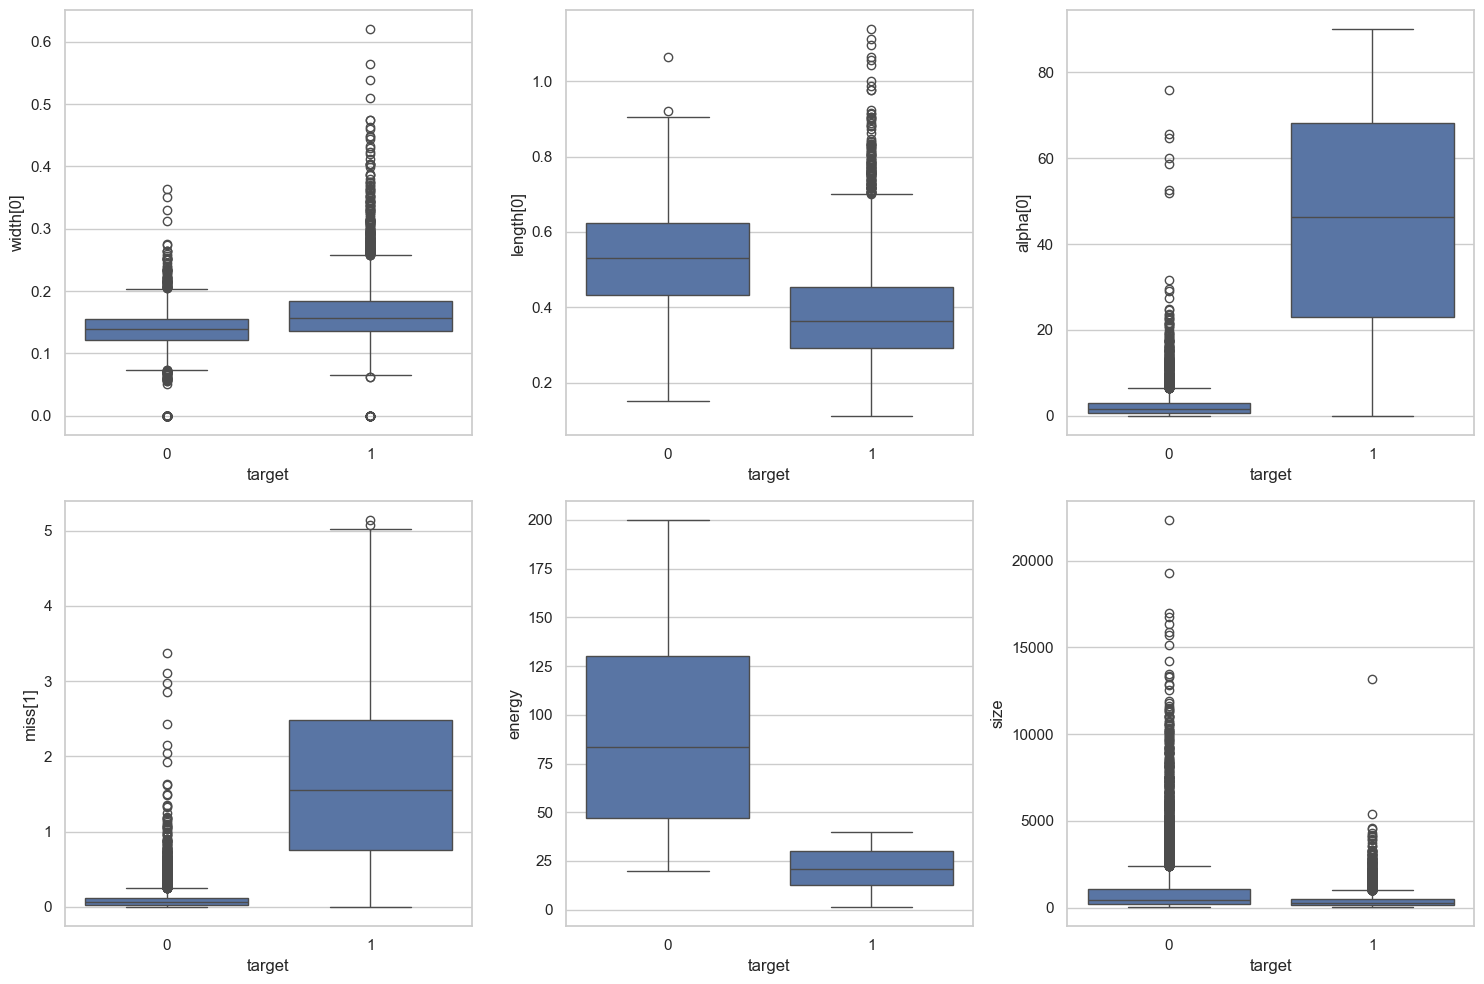

In [103]:
# Подсказки:
# 1. Постройте boxplot или violinplot для тех же признаков.
# 2. Удобные функции: sns.boxplot(data=df, x="target", y=feature) или sns.violinplot(...).
# 3. Используйте цикл по features_to_plot, если хотите построить несколько графиков.
# 4. Обратите внимание на медианы, разброс и выбросы.

# Ваш код:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
sns.boxplot(data=df, x='target', y='width[0]', ax=axes[0, 0])
sns.boxplot(data=df, x='target', y='length[0]', ax=axes[0, 1])
sns.boxplot(data=df, x='target', y='alpha[0]', ax=axes[0, 2])
sns.boxplot(data=df, x='target', y='miss[1]', ax=axes[1, 0])
sns.boxplot(data=df, x='target', y='energy', ax=axes[1, 1])
sns.boxplot(data=df, x='target', y='size', ax=axes[1, 2])
plt.tight_layout()
plt.show()

### Промежуточный вывод 6

Ответьте:

- Какие признаки имеют заметно разные распределения для `gamma` и `proton`?
- Какие признаки почти не разделяют классы визуально?
- Есть ли признаки с сильными выбросами?
- Какие признаки стоит оставить кандидатами для модели по итогам визуального анализа?

**Ваш вывод:**

> 1. Признак alpha[0] имеет разные распределения для proton и gamma, у gamma мощный взрыв возле нуля а у proton плоский, также energy у протонов только до 50 и большее кол-во зажато именно в этом промежутке в то время как у energy у gamma распределение широкое и до 200, miss[1] аналогично alpha[0]. также длина - length[0], у proton пик смещен влево в то время как length[0] у gamma сосредоточен в бОльших значениях
> 2. size и width[0], так как на гистограмме наши графики почти полностью накладываются друг на друга, а по boxplot выглядят не сильно отличимыми
> 3. Да, это size, width[0], miss[1] и length[0]. в случае size выбросов много и достигают 20000+, у width[0] выбросы уходят в 0.2-0.6
> 4. alpha[0], energy, length[0] остаются кандитатами по итогам визуального анализа

<span style="background-color: #d9ead3; color: #274e13; padding: 2px 6px; border-radius: 4px;"><b>Проверка:</b> базовый визуальный анализ начат правильно.</span> Ты построил гистограммы с разделением по `target`, использовал `stat='density'`, `common_norm=False`, `kde=True`, а также добавил boxplot для оценки медиан, разброса и выбросов. В выводе есть попытка не просто перечислить признаки, а описать форму распределений: например, что `alpha[0]` у `gamma` сконцентрирован около нуля, а у `proton` распределен шире.

<span style="background-color: #f4cccc; color: #990000; padding: 2px 6px; border-radius: 4px;"><b>Ошибка:</b> задание выполнено не для всех обязательных признаков.</span> В `features_to_plot` ты записал обязательный список: `width[0]`, `length[0]`, `alpha[0]`, `miss[1]`, `azwidth[1]`, `dist[1]`, `Xc[0]`, `Yc[0]`, `numb_pix`, но на графиках реально построил только `width[0]`, `length[0]`, `alpha[0]`, `miss[1]`, `energy`, `size`. Получается, что `azwidth[1]`, `dist[1]`, `Xc[0]`, `Yc[0]`, `numb_pix` не были визуально проверены, хотя задание прямо просило начать с них. Нужно либо построить графики для всех признаков из `features_to_plot` циклом, либо явно расширить сетку графиков и добавить недостающие признаки.

<span style="background-color: #f4cccc; color: #990000; padding: 2px 6px; border-radius: 4px;"><b>Ошибка:</b> вывод по кандидатам для модели пока неполный, потому что он сделан по неполному набору графиков.</span> Например, `numb_pix`, `azwidth[1]`, `dist[1]`, `Xc[0]`, `Yc[0]` не попали в визуальный анализ, поэтому нельзя честно сказать, какие признаки почти не разделяют классы, а какие стоит оставить кандидатами. Сначала нужно построить распределения для всех обязательных признаков, а потом обновить вывод по каждому пункту задания.

<span style="background-color: #fff2cc; color: #7f6000; padding: 2px 6px; border-radius: 4px;"><b>Совет:</b> `energy` стоит пометить как спорный признак.</span> По графикам он может хорошо разделять классы, но для будущей модели важно отдельно проверить, нет ли здесь утечки информации: доступна ли такая величина в реальном сценарии применения модели и не является ли она результатом знания о типе события. Пока лучше писать не "оставить кандидатом", а "выглядит информативно, но требует проверки на утечку".

## Задание 7. Исследовать корреляцию признаков с таргетом

Так как `target` закодирован числами `0` и `1`, обычная корреляция Пирсона между числовым признаком и `target` показывает линейную связь признака с классом.

Интерпретация:

- положительная корреляция: большие значения признака чаще соответствуют `proton`;
- отрицательная корреляция: большие значения признака чаще соответствуют `gamma`;
- корреляция около нуля не означает, что признак бесполезен: связь может быть нелинейной.

/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


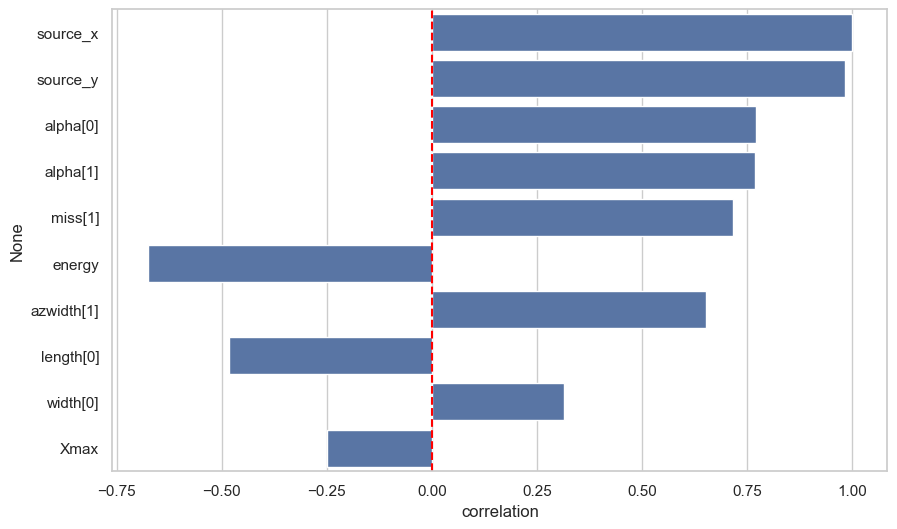

In [123]:
# Подсказки:
# 1. Посчитайте корреляцию каждого числового признака с df["target"].
# 2. Удобный метод: .corrwith(...).
# 3. Добавьте колонку с модулем корреляции, чтобы отсортировать признаки по силе связи.
# 4. Сохраните таблицу корреляций в переменную corr_with_target.
# 5. Выведите признаки с самой большой корреляцией по модулю.

# Ваш код:
correlations = df[numeric_columns].corrwith(df["target"])
corr_with_target = pd.DataFrame(correlations, columns=["correlation"])
corr_with_target["abs_correlation"] = corr_with_target["correlation"].abs()
corr_with_target = corr_with_target.sort_values(by="abs_correlation", ascending=False)
corr_with_target.head(10)


top_features = corr_with_target.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_features["correlation"], y=top_features.index)

plt.axvline(0, color="red", linestyle="--")

plt.show()

### Промежуточный вывод 7

Ответьте:

- Какие признаки сильнее всего связаны с `target` по модулю корреляции?
- Какие признаки имеют положительную корреляцию с `target`, то есть больше характерны для `proton`?
- Какие признаки имеют отрицательную корреляцию с `target`, то есть больше характерны для `gamma`?
- Совпадают ли результаты корреляции с выводами по распределениям?

**Ваш вывод:**

> 1. сильнее всего связаны с target по модулю корреляции - source_x, source_y, alpha[0], alpha[1], miss[1] и energy
> 2. больше характерны для proton - source_x, source_y, alpha[0], alpha[1], miss[1], azwidth[1], width[0]
> 3. больше характерны для gamma - energy, length[0], Xmax
> 4. да! т.к на гистограмме мы видели что alpha[0] для gamma всегда около нуля и здесь положительная связь с alpha[0] для proton т.е большие углы - proton. Также energy, для gamma он был распределен до высоких значений и тут мы видим корелляцию с energy и gamma

<span style="background-color: #d9ead3; color: #274e13; padding: 2px 6px; border-radius: 4px;"><b>Проверка:</b> корреляции с `target` посчитаны технически правильно.</span> Ты использовал `corrwith(df["target"])`, добавил модуль корреляции, отсортировал признаки по `abs_correlation` и построил barplot для топ-признаков. Вывод по самым сильным признакам в целом совпадает с расчетом: `source_x`, `source_y`, `alpha[0]`, `alpha[1]`, `miss[1]`, `energy`.

<span style="background-color: #d9ead3; color: #274e13; padding: 2px 6px; border-radius: 4px;"><b>Проверка:</b> знаки корреляций в основном интерпретированы правильно.</span> Положительные корреляции у `source_x`, `source_y`, `alpha[0]`, `alpha[1]`, `miss[1]`, `azwidth[1]`, `width[0]` означают, что большие значения чаще встречаются у `proton`. Отрицательные корреляции у `energy`, `length[0]`, `Xmax` означают, что большие значения чаще встречаются у `gamma`.

<span style="background-color: #f4cccc; color: #990000; padding: 2px 6px; border-radius: 4px;"><b>Ошибка:</b> `source_x` и `source_y` нельзя просто принять как сильные полезные признаки без дополнительной проверки.</span> У `source_x` корреляция с `target` равна `1.0`, а у `source_y` почти `0.98`, это слишком сильный сигнал для обычного физического признака события. Нужно отдельно проверить, почему координаты источника почти напрямую кодируют класс: возможно, это особенность генерации/подготовки данных или источник утечки. В выводе нужно написать, что такие признаки требуют проверки и не должны автоматически попадать в итоговый набор.

<span style="background-color: #fff2cc; color: #7f6000; padding: 2px 6px; border-radius: 4px;"><b>Совет:</b> связь с выводами по распределениям описана только частично.</span> Ты хорошо объяснил совпадение для `alpha[0]` и `energy`, но стоит также упомянуть `miss[1]` и `azwidth[1]`, потому что они тоже входят в топ корреляций и должны сопоставляться с визуальным анализом. При этом нужно помнить, что в задании 6 часть обязательных графиков не была построена, поэтому сравнение корреляций с распределениями пока неполное.

<span style="background-color: #fff2cc; color: #7f6000; padding: 2px 6px; border-radius: 4px;"><b>Совет:</b> визуальное представление корреляций стоит доработать.</span> Для анализа корреляций часто полезно вывести не только график, но и таблицу с конкретными численными значениями корреляций, например `corr_with_target.head(10)`, чтобы сразу видеть силу связи и знак. Также стоит настроить размер графика и подписи: сейчас barplot может отображаться не полностью или быть трудным для чтения, поэтому лучше увеличить `figsize`, добавить подписи осей и `plt.tight_layout()`.

## Задание 8. Проверить корреляции между признаками

Если два признака почти полностью повторяют друг друга, модель может не получить от них новой информации. Постройте тепловую карту корреляций между наиболее перспективными признаками.

Сначала выберите признаки с наибольшей связью с `target`, затем посмотрите, нет ли среди них сильно коррелирующих пар.

<Axes: >

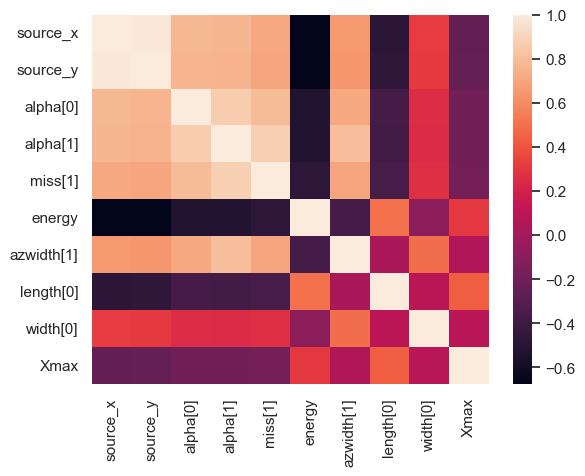

In [127]:
# Подсказки:
# 1. Выберите 10-15 наиболее перспективных признаков.
# 2. Посчитайте матрицу корреляций между ними через .corr().
# 3. Постройте heatmap через sns.heatmap(...).
# 4. Найдите пары признаков с очень высокой корреляцией между собой.

# Ваш код:
top_featureschoice = corr_with_target.head(10).index
matrix = df[top_featureschoice].corr()
sns.heatmap(matrix)

### Промежуточный вывод 8

Ответьте:

- Есть ли пары признаков с очень высокой корреляцией между собой?
- Нужно ли удалять один из таких признаков уже сейчас или лучше оставить решение до этапа обучения моделей?
- Какие признаки после этого шага остаются наиболее перспективными?

**Ваш вывод:**

> 1. да, это пара source_x и source_y с корреляцией 1.0, также с немного меньшей корреляцией alpha[0], alpha[1] и miss[1], alpha[1]
> 2. я думаю что удаление этих признаков будет следующим этапом так как сейчас мы только наблюдаем и фиксируем эти корреляции
> 3. alpha[0] или же alpha[1], miss[1], energy, length[0].

<span style="background-color: #d9ead3; color: #274e13; padding: 2px 6px; border-radius: 4px;"><b>Проверка:</b> общий подход к проверке корреляций между признаками выбран правильно.</span> Ты взял топ-признаки по связи с `target`, посчитал для них матрицу корреляций через `.corr()` и построил heatmap. Это соответствует заданию: сначала выбрать перспективные признаки, потом посмотреть, нет ли среди них сильно связанных пар.

<span style="background-color: #f4cccc; color: #990000; padding: 2px 6px; border-radius: 4px;"><b>Ошибка:</b> вывод про пару `source_x` и `source_y` написан как корреляция `1.0`, но по фактической матрице между признаками там примерно `0.98`, а не ровно `1.0`.</span> Ровно `1.0` у `source_x` было в предыдущем задании как корреляция с `target`, и эти две вещи нельзя смешивать. Нужно аккуратно различать: корреляция признака с `target` и корреляция между двумя признаками.

<span style="background-color: #f4cccc; color: #990000; padding: 2px 6px; border-radius: 4px;"><b>Ошибка:</b> в heatmap попали `source_x` и `source_y`, хотя в предыдущем задании они уже выглядят подозрительно из-за почти прямой связи с классом.</span> Если признаки могут быть источником утечки, их нельзя без комментария использовать как "наиболее перспективные" в анализе взаимных корреляций. Нужно либо отдельно пометить их как спорные, либо построить дополнительную heatmap без `source_x` и `source_y`, чтобы посмотреть связи между более физически осмысленными признаками.

<span style="background-color: #fff2cc; color: #7f6000; padding: 2px 6px; border-radius: 4px;"><b>Совет:</b> heatmap стоит сделать информативнее.</span> Сейчас `sns.heatmap(matrix)` не показывает численные значения корреляций и может быть трудно читаемым. Лучше добавить `annot=True`, `fmt=".2f"`, настроить `figsize`, выбрать понятную цветовую шкалу и вызвать `plt.tight_layout()`. Тогда вывод про пары с высокой корреляцией будет проще проверить прямо по графику.

<span style="background-color: #fff2cc; color: #7f6000; padding: 2px 6px; border-radius: 4px;"><b>Совет:</b> вывод по решению "удалять или оставить" стоит сделать точнее.</span> Идея не удалять признаки сразу на этапе разведочного анализа нормальная, но нужно явно сказать, что сильно коррелирующие пары стоит держать на контроле для этапа обучения: например, сравнить качество модели с обоими признаками и с одним из пары, а также проверить важность признаков. Особенно это касается пар `alpha[1]` - `miss[1]`, `alpha[0]` - `alpha[1]`, `alpha[1]` - `azwidth[1]`.

## Задание 9. Сформировать итоговый набор признаков

Соберите итоговый список `selected_features` для следующей работы с моделями.

Критерии выбора:

- признак есть и у `gamma`, и у `proton`;
- признак числовой;
- признак не является `target` или идентификатором события;
- распределения признака отличаются между классами или есть заметная связь с `target`;
- если признак исключен, вы можете объяснить почему.

In [137]:
# Подсказки:
# 1. Создайте список selected_features вручную по итогам предыдущих заданий.
# 2. В список должны попасть только признаки, которые есть в df и подходят для модели.
# 3. Не включайте target и идентификаторы событий.
# 4. Проверьте список: все выбранные признаки должны быть в numeric_columns.
# 5. Выведите итоговый список и его длину.

# Ваш код:
selected_features = [
    'alpha[0]', 'alpha[1]', 'miss[1]', 'length[0]', 'azwidth[1]', 'width[0]', 'size', 'source_x'
]

print('Список признаков:', selected_features)
print('Длина списка:', len(selected_features))

Список признаков: ['alpha[0]', 'alpha[1]', 'miss[1]', 'length[0]', 'azwidth[1]', 'width[0]', 'size', 'source_x']
Длина списка: 8


## Итоговый вывод

Заполните в конце работы:

1. Какие файлы были считаны и как был задан `target`?
2. Какие признаки визуально лучше всего разделяют `gamma` и `proton`?
3. Какие признаки сильнее всего коррелируют с `target`?
4. Какие признаки были исключены и почему?
5. Какой итоговый список `selected_features` вы предлагаете использовать для обучения моделей?

**Ваш итоговый вывод:**

> 1. мы считали файлы gamma.csv и proton.csv, target был задан через копии gamma/proton и классификацией 0 для gamma, 1 для proton
> 2. Лучше всего визуально отличают gamma и proton - alpha[0], energy, length[0]
> 3. Признаки которые сильнее всего коррелируют с target - source_x, source_y, alpha[0], alpha[1], miss[1] и energy
> 4. alpha[0], alpha[1], miss[1], length[0], azwidth[1], width[0], size, source_x

## Общие впечатления по проверке

<span style="background-color: #d9ead3; color: #274e13; padding: 2px 6px; border-radius: 4px;"><b>Общее впечатление:</b> работа понравилась.</span> Видно, что ты старался и в основном писал код и выводы самостоятельно. Это очень ценно: самостоятельная работа с данными важнее, чем идеально гладкий результат с первого раза.

<span style="background-color: #fff2cc; color: #7f6000; padding: 2px 6px; border-radius: 4px;"><b>Что дальше:</b> к заданию 9 и итоговому списку `selected_features` вернусь после того, как ты исправишь замечания по предыдущим заданиям.</span> Сейчас важно сначала поправить логику анализа, особенно работу с уникальными колонками, пропусками, спорными признаками и визуализациями.

<span style="background-color: #d9ead3; color: #274e13; padding: 2px 6px; border-radius: 4px;"><b>Напутствие:</b> ошибок не нужно бояться - им нужно радоваться.</span> Ошибки - это всегда точки роста: они показывают, где можно стать сильнее в анализе данных, интерпретации графиков и выборе признаков. Успехов, жду с нетерпением исправленного варианта.